# Eksplorativna analiza podataka

**Problem:** Selekcija algoritma pretrage na osnovu stabla igre 

**Pitanje:** Može li se iz strukturnih karakteristika stabla predvideti koji algoritam između Alpha-Beta ili MCTS pronalazi optimalni prvi potez, i čiji je izabrani potez bolji? 

**Skup podataka:** 16978 sintetičkih stabala igre, 91 atribut

## 1. Učitavanje podataka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from theme import *

In [2]:
Path("../plots/eda").mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv("../data/trees10.csv")
df.head()

,branching_factor,depth,chance_node_density,heur_noise_param,total_nodes,total_leaves,total_internal_nodes,total_chance_nodes,total_max_nodes,total_min_nodes,...,ab_correct,mcts_correct,mcts_correct_rate,which_algo,margin_category,is_contested,which_better,delta,ab_regret,mcts_regret
0,12,3,0.000000,0.728892,1214,1116,98,0,90,8,...,0,0,0.0,Neither,low,1,Tie,0.000000,0.004710,0.004710
1,4,8,0.056796,1.141444,15619,11308,4311,215,947,3149,...,1,1,1.0,Both,medium,0,Tie,0.000000,0.000000,0.000000
2,13,2,0.000000,0.253625,214,199,15,0,1,14,...,1,1,1.0,Both,high,0,Tie,0.000000,0.000000,0.000000
3,5,6,0.000000,0.711080,11047,8769,2278,0,413,1865,...,0,0,0.0,Neither,low,1,MCTS,-0.075324,0.077225,0.001902
4,9,4,0.621402,0.978048,7669,6866,803,510,22,271,...,1,1,0.8,Both,medium,0,AB,0.065258,0.000000,0.065258


In [4]:
print(f"Broj slogova: {len(df)}")
print(f"Broj atributa: {len(df.columns)}")

Broj slogova: 16978
Broj atributa: 91


## 2. Tipovi atributa i nedostajuće vrednosti

In [5]:
df.dtypes.value_counts()

float64    62
int64      26
str         3
Name: count, dtype: int64

In [6]:
df.select_dtypes(exclude="number").columns.tolist()

['which_algo', 'margin_category', 'which_better']

In [7]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

## 3. Opisna statistika

In [8]:
df.select_dtypes("number").describe().transpose().round(3)

,count,mean,std,min,25%,50%,75%,max
branching_factor,16978.0,8.387,3.451,2.000,5.000,9.000,11.000,14.000
depth,16978.0,3.968,1.668,2.000,3.000,4.000,5.000,10.000
chance_node_density,16978.0,0.383,0.289,0.000,0.104,0.369,0.638,0.900
heur_noise_param,16978.0,0.751,0.434,0.000,0.371,0.756,1.130,1.500
total_nodes,16978.0,5598.903,8369.602,80.000,278.000,1472.000,7548.500,51771.000
...,...,...,...,...,...,...,...,...
mcts_correct_rate,16978.0,0.531,0.423,0.000,0.000,0.600,1.000,1.000
is_contested,16978.0,0.344,0.475,0.000,0.000,0.000,1.000,1.000
delta,16978.0,0.027,0.381,-1.874,-0.036,0.000,0.094,1.999
ab_regret,16978.0,0.186,0.309,0.000,0.000,0.000,0.274,1.875


## 4. Ciljni atributi

- **`which_algo`** (nominalna, 4 klase): koji algoritam je pronašao optimalni potez: AB / MCTS / Both / Neither
- **`which_better`** (nominalna, 3 klase): čiji je izabrani potez bolji, bez obzira da li je optimalan: AB / MCTS / Tie
- **`margin_category`** (ordinalna, 3 klase): za koliko pobednik vodi: low / medium / high
- **`ab_correct`**, **`mcts_correct`** (binarne): da li je svaki algoritam pojedinačno bio tačan
- **`mcts_correct_rate`** (kontinualna): udeo od 5 ponavljanja MCTS-a koji su pogodili optimum, merilo pouzdanosti
- **`is_contested`** (binarna): identično `margin_category == "low"` 

**Razlika između `which_algo` i `which_better`:** prvo pita ko je pogodio *tačan* odgovor, drugo čiji je potez *bolji*. Algoritam koji promaši optimum ali izabere drugi najbolji potez gubi po `which_algo` a može dobiti po `which_better`.

In [9]:
df["which_algo"].value_counts()

which_algo
Both       6203
Neither    5445
MCTS       2756
AB         2574
Name: count, dtype: int64

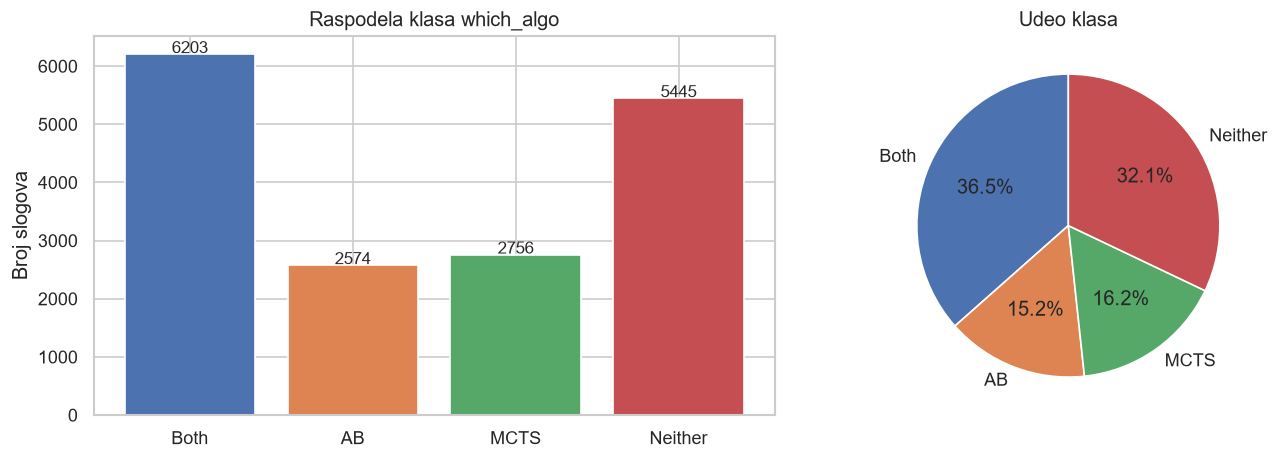

In [10]:
counts = df["which_algo"].value_counts().reindex(CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(counts.index, counts.values, color=[CLASS_COLORS[c] for c in counts.index])
axes[0].set_title("Raspodela klasa which_algo")
axes[0].set_ylabel("Broj slogova")
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 20, str(v), ha="center", fontsize=10)

axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=[CLASS_COLORS[c] for c in counts.index],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Udeo klasa")

plt.tight_layout()
plt.savefig("../plots/eda/01_class_distribution.png", bbox_inches="tight")
plt.show()

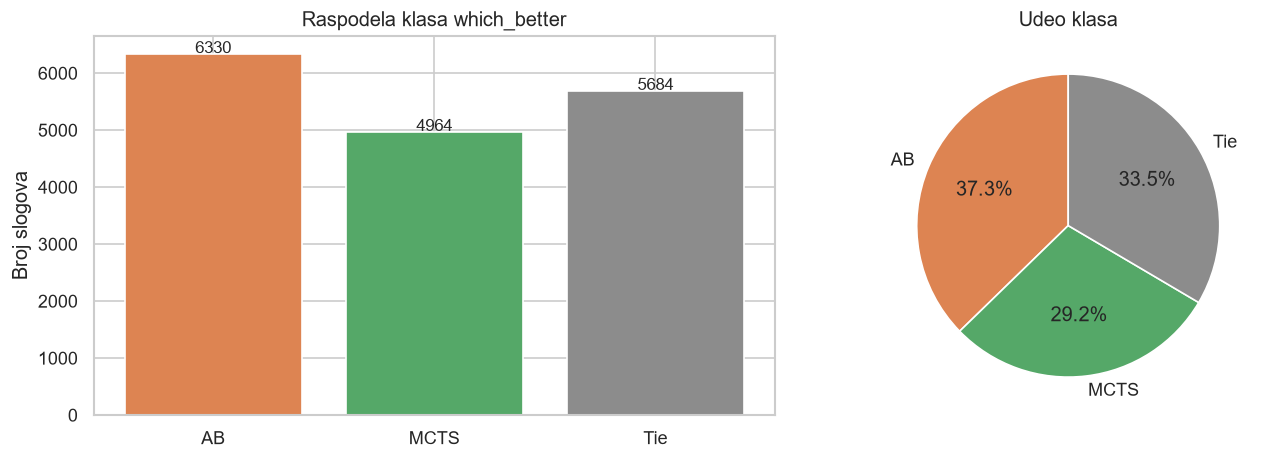

In [11]:
from theme import BETTER_ORDER, BETTER_COLORS

counts_better = df["which_better"].value_counts().reindex(BETTER_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(counts_better.index, counts_better.values, color=[BETTER_COLORS[c] for c in counts_better.index])
axes[0].set_title("Raspodela klasa which_better")
axes[0].set_ylabel("Broj slogova")
for bar, v in zip(bars, counts_better.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 20, str(v), ha="center", fontsize=10)

axes[1].pie(
    counts_better.values,
    labels=counts_better.index,
    colors=[BETTER_COLORS[c] for c in counts_better.index],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Udeo klasa")

plt.tight_layout()
plt.savefig("../plots/eda/01b_which_better_distribution.png", bbox_inches="tight")
plt.show()


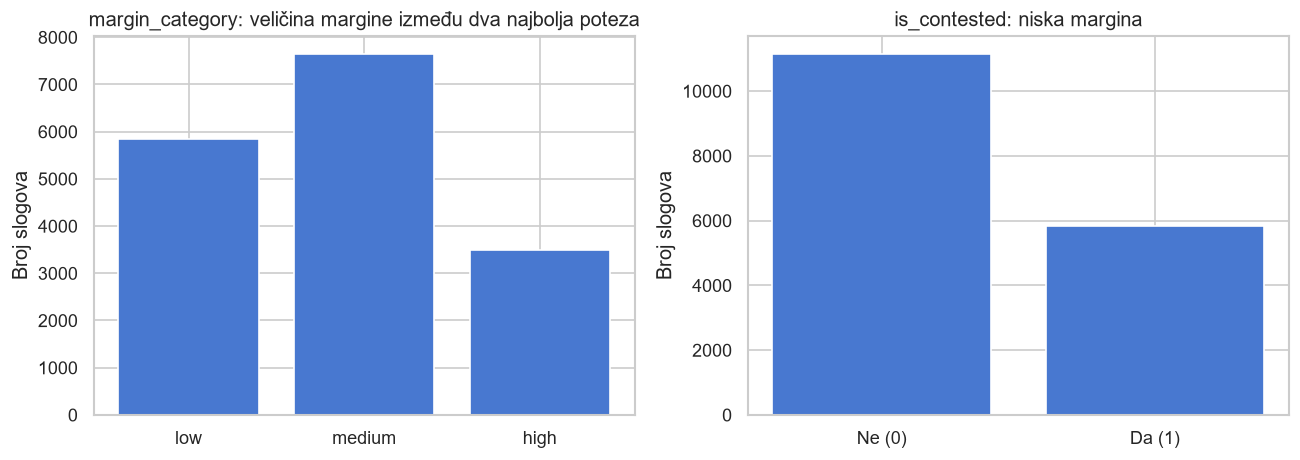

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

mc = df["margin_category"].value_counts().reindex(["low", "medium", "high"])
axes[0].bar(mc.index, mc.values)
axes[0].set_title("margin_category: veličina margine između dva najbolja poteza")
axes[0].set_ylabel("Broj slogova")

vc = df["is_contested"].value_counts().sort_index()
axes[1].bar(["Ne (0)", "Da (1)"], vc.values)
axes[1].set_title("is_contested: niska margina")
axes[1].set_ylabel("Broj slogova")

plt.tight_layout()
plt.savefig("../plots/eda/02_target_margin.png", bbox_inches="tight")
plt.show()

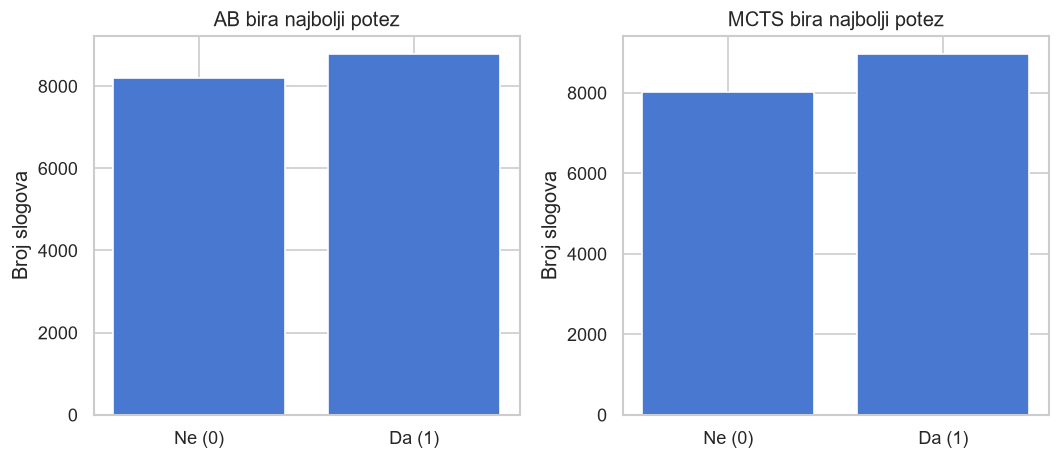

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, col, title in zip(axes, ["ab_correct", "mcts_correct"], ["AB bira najbolji potez", "MCTS bira najbolji potez"]):
    vc = df[col].value_counts().sort_index()
    ax.bar(["Ne (0)", "Da (1)"], vc.values)
    ax.set_title(title)
    ax.set_ylabel("Broj slogova")

plt.tight_layout()
plt.savefig("../plots/eda/03_binary_targets.png", bbox_inches="tight")
plt.show()

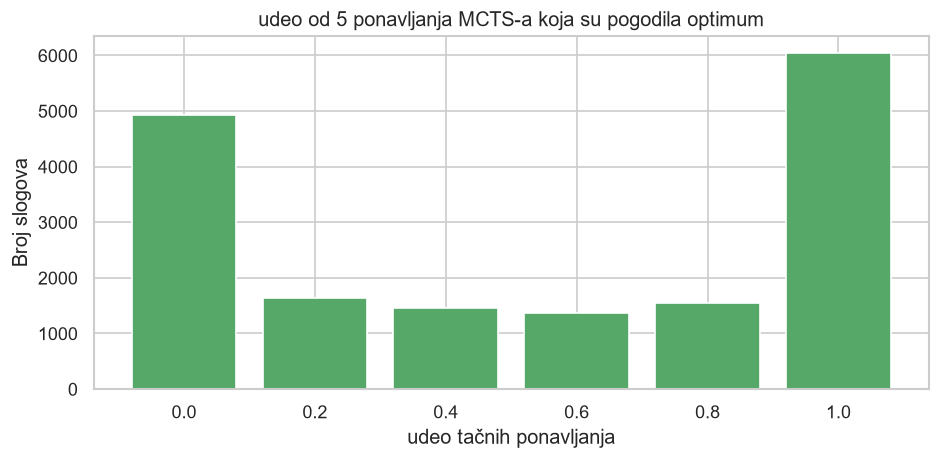

Potpuno stabilno (svih 5 se slaze): 64.6%
Delimicno neslaganje: 35.4%


In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

mc = df["mcts_correct_rate"].value_counts().sort_index()
ax.bar([f"{x:.1f}" for x in mc.index], mc.values, color=XGB_COLOR)
ax.set_title("udeo od 5 ponavljanja MCTS-a koja su pogodila optimum")
ax.set_xlabel("udeo tačnih ponavljanja")
ax.set_ylabel("Broj slogova")

plt.tight_layout()
plt.savefig("../plots/eda/03b_mcts_correct_rate.png", bbox_inches="tight")
plt.show()

stabilno = ((df["mcts_correct_rate"] == 0) | (df["mcts_correct_rate"] == 1)).mean()
print(f"Potpuno stabilno (svih 5 se slaze): {stabilno:.1%}")
print(f"Delimicno neslaganje: {1 - stabilno:.1%}")


## 5. Raspodela parametara stabla

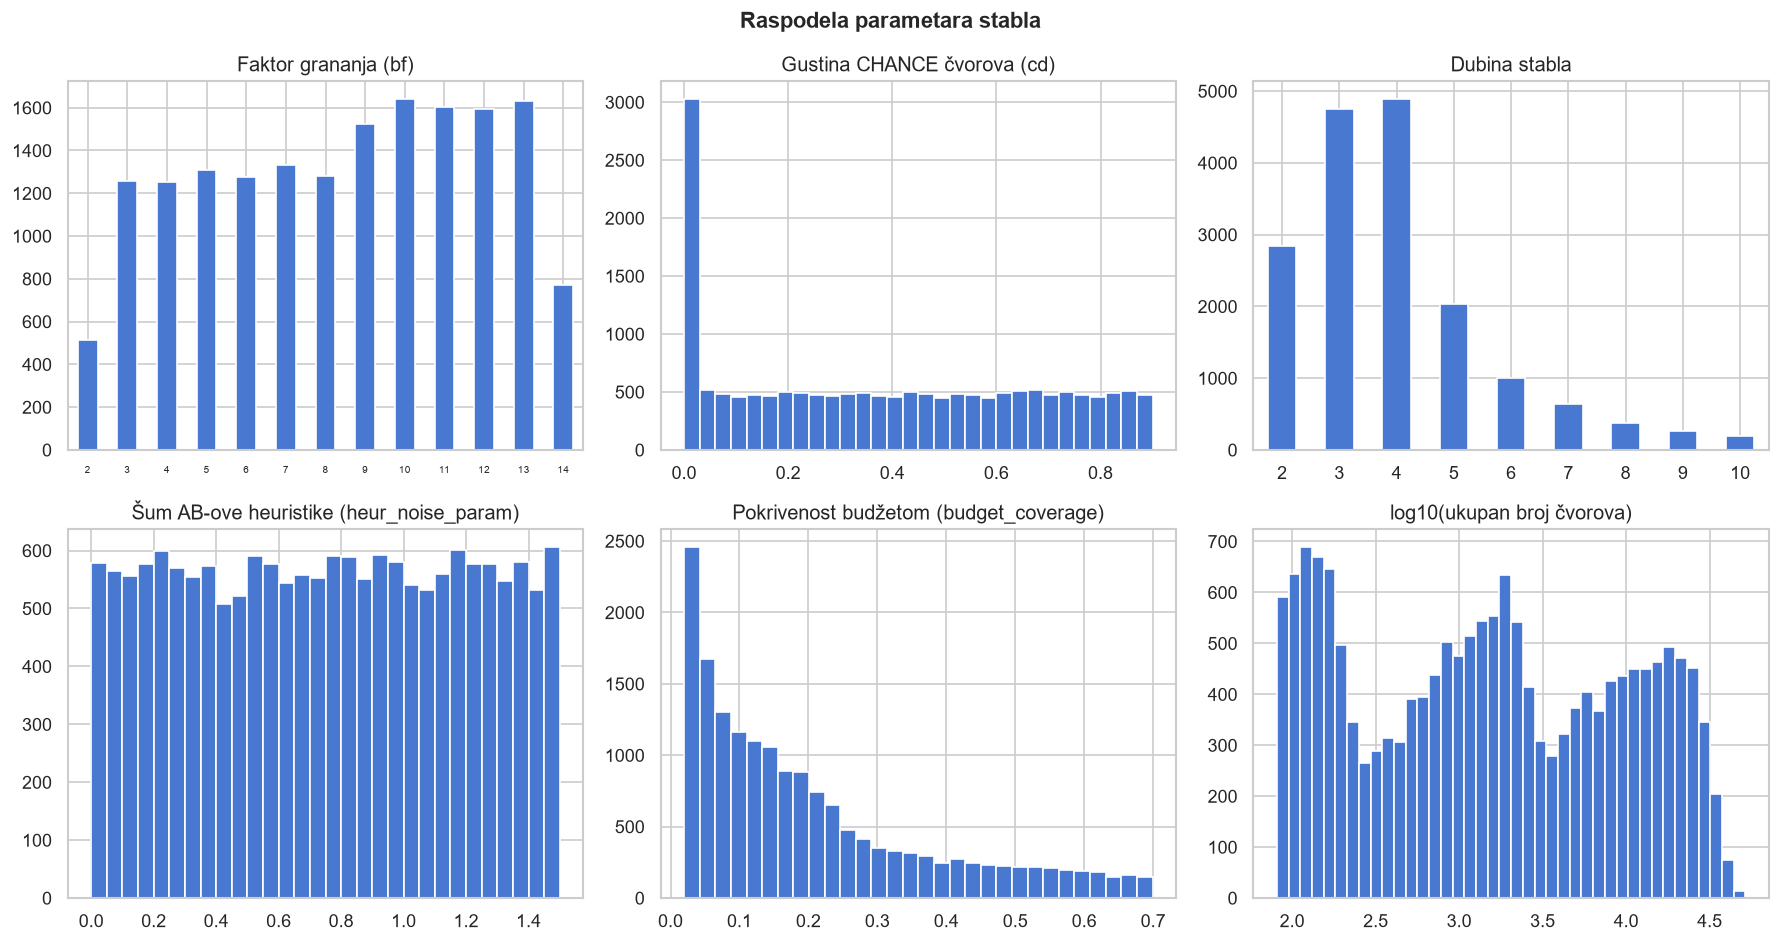

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

df["branching_factor"].value_counts().sort_index().plot.bar(ax=axes[0, 0], rot=0)
axes[0, 0].set_title("Faktor grananja (bf)")
axes[0, 0].tick_params(axis="x", labelsize=6)

axes[0, 1].hist(df["chance_node_density"], bins=30)
axes[0, 1].set_title("Gustina CHANCE čvorova (cd)")

df["depth"].value_counts().sort_index().plot.bar(ax=axes[0, 2], rot=0)
axes[0, 2].set_title("Dubina stabla")

axes[1, 0].hist(df["heur_noise_param"], bins=30)
axes[1, 0].set_title("Šum AB-ove heuristike (heur_noise_param)")

axes[1, 1].hist(df["budget_coverage"], bins=30)
axes[1, 1].set_title("Pokrivenost budžetom (budget_coverage)")

axes[1, 2].hist(np.log10(df["total_nodes"] + 1), bins=40)
axes[1, 2].set_title("log10(ukupan broj čvorova)")

for ax in axes.flat:
    ax.set_xlabel("")

plt.suptitle("Raspodela parametara stabla", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/eda/04_parameter_distribution.png", bbox_inches="tight")
plt.show()

## 6. Atributi po klasama

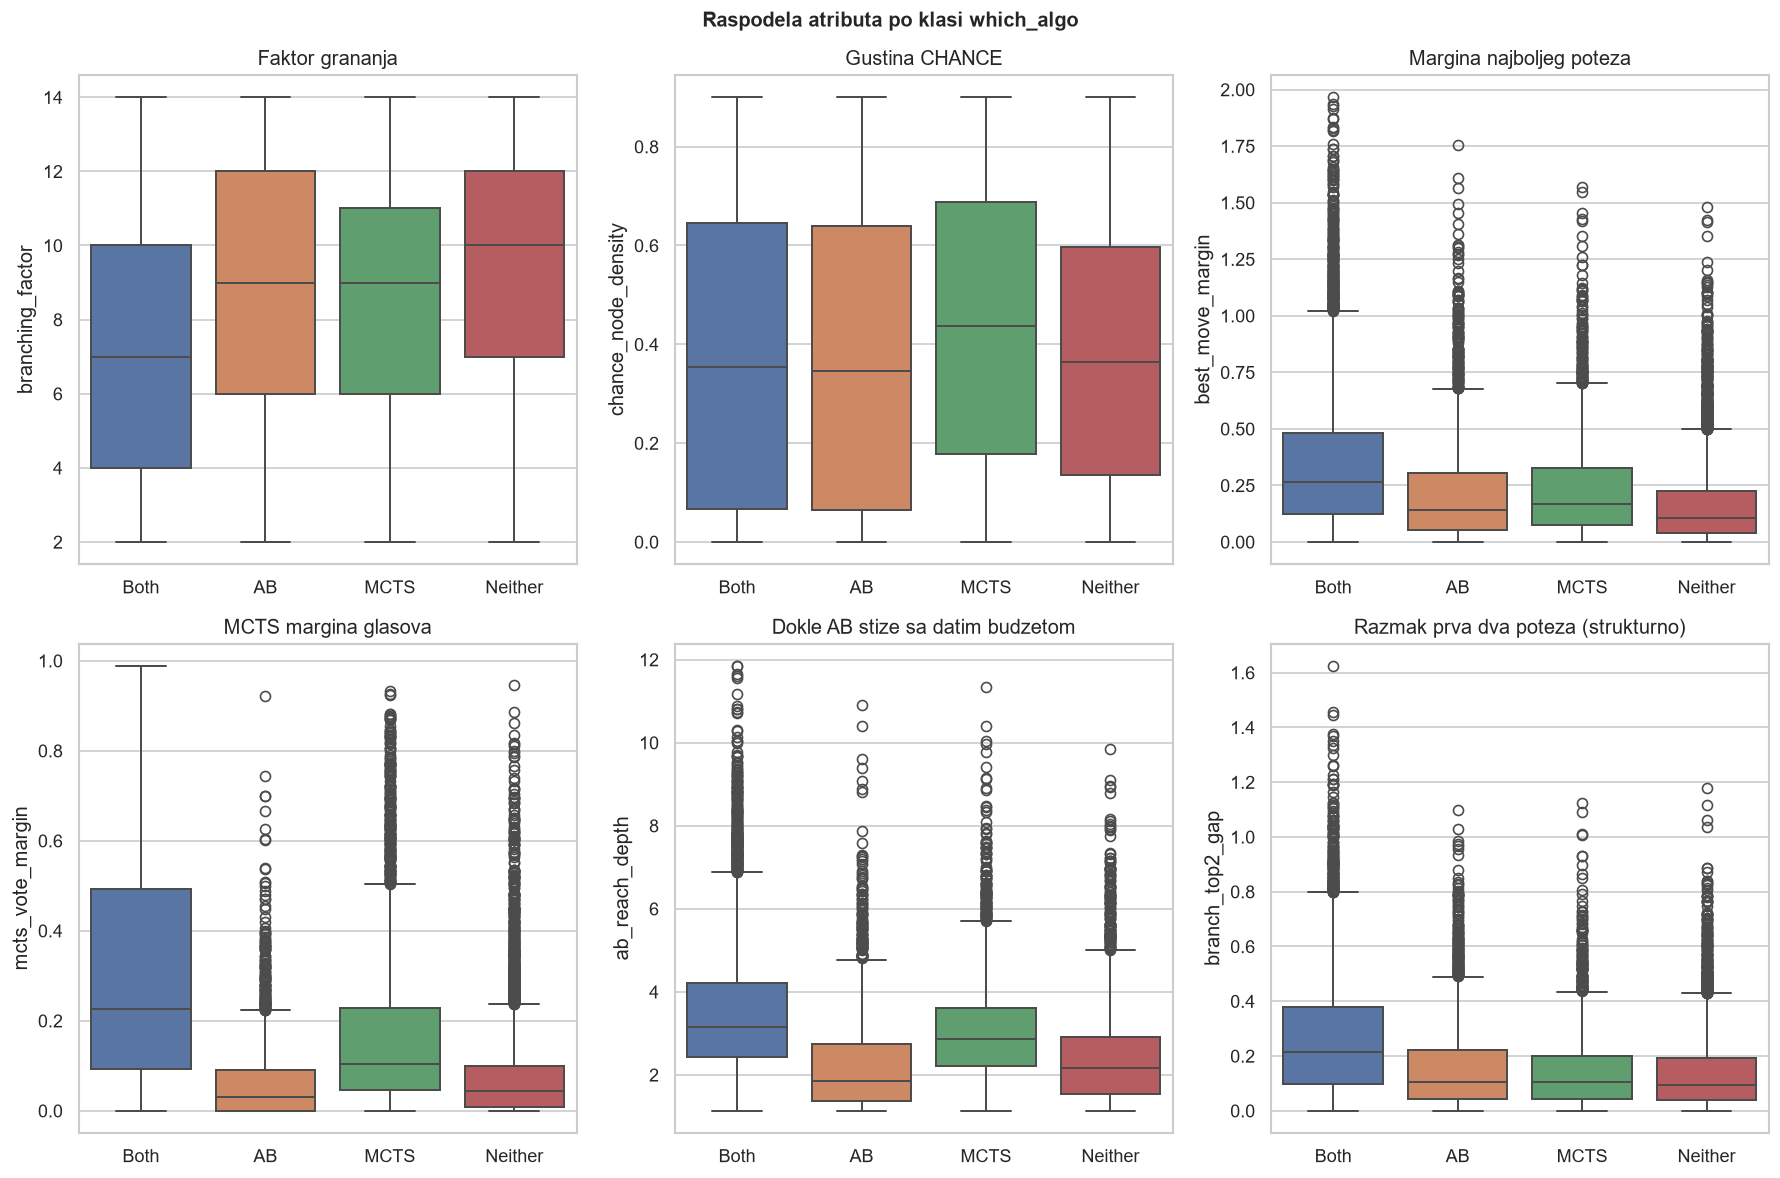

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

cols = [
    "branching_factor", "chance_node_density", "best_move_margin",
    "mcts_vote_margin", "ab_reach_depth", "branch_top2_gap"
]
titles = [
    "Faktor grananja", "Gustina CHANCE", "Margina najboljeg poteza",
    "MCTS margina glasova", "Dokle AB stize sa datim budzetom", "Razmak prva dva poteza (strukturno)"
]

for ax, col, title in zip(axes.flat, cols, titles):
    sns.boxplot(
        data=df, x="which_algo", y=col,
        hue="which_algo", order=CLASS_ORDER, palette=CLASS_COLORS,
        legend=False, ax=ax, linewidth=1.2
    )
    ax.set_title(title)
    ax.set_xlabel("")

plt.suptitle("Raspodela atributa po klasi which_algo", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/eda/05_feature_boxplots.png", bbox_inches="tight")
plt.show()

## 7. Analiza autlajera

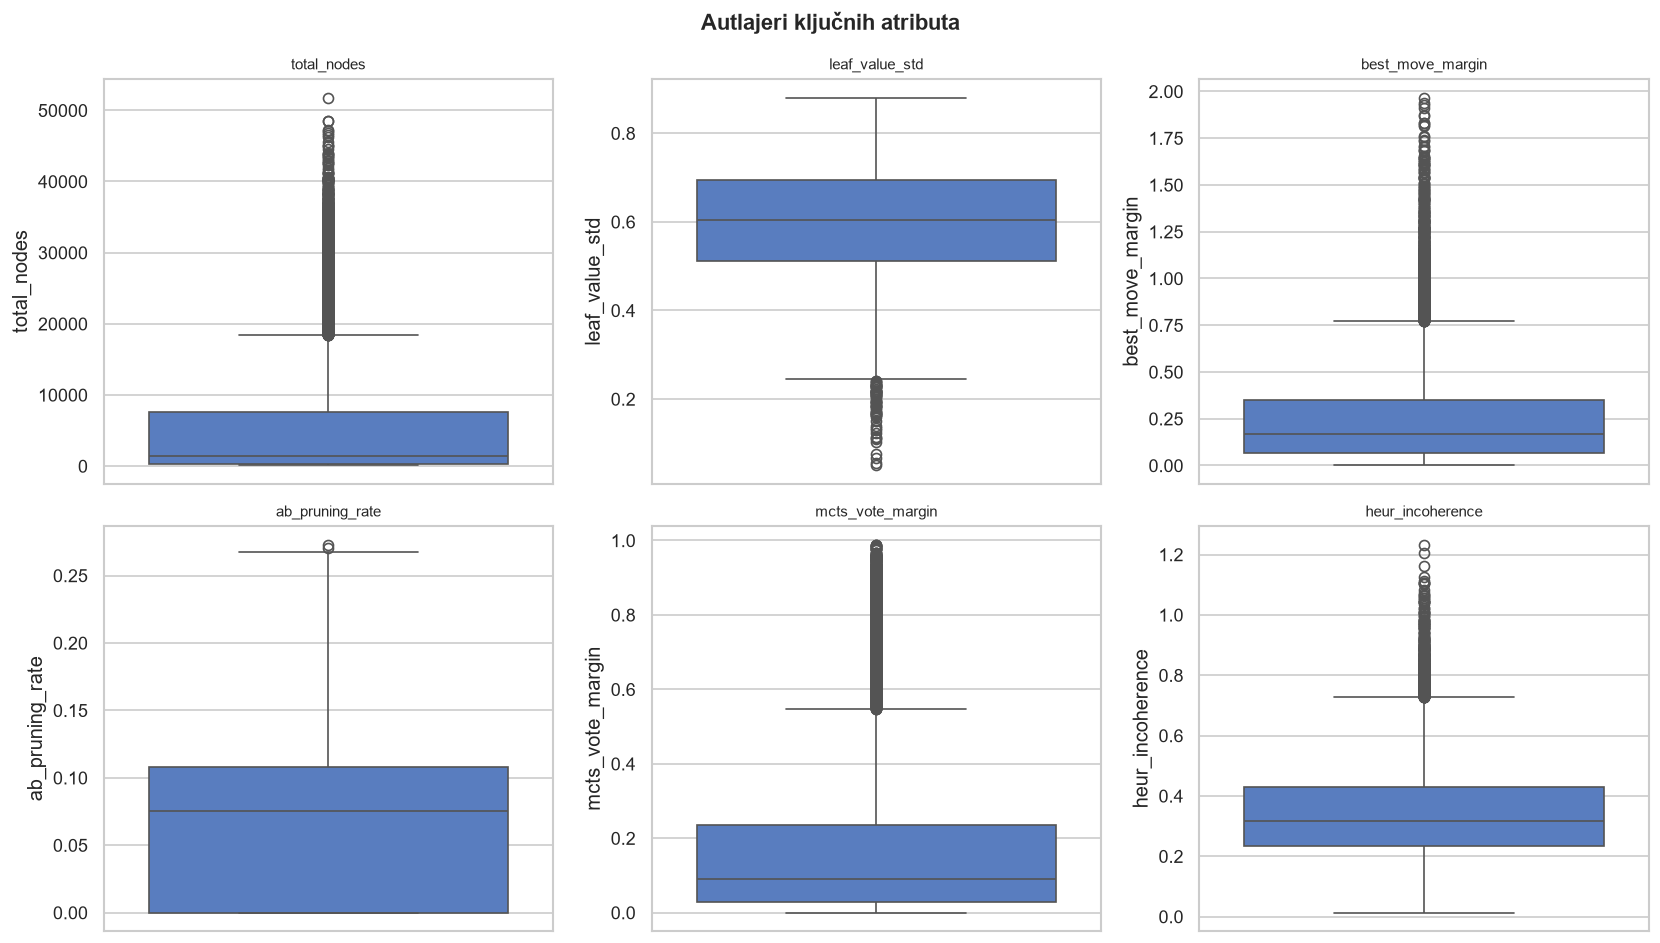

In [17]:
outlier_cols = [
    "total_nodes", "leaf_value_std", "best_move_margin",
    "ab_pruning_rate", "mcts_vote_margin", "heur_incoherence",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, outlier_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")

plt.suptitle("Autlajeri ključnih atributa", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/eda/06_outliers_iqr.png", bbox_inches="tight")
plt.show()

## 8. Korelaciona analiza

Koji atributi su najpovezaniji sa tačnošću svakog algoritma?

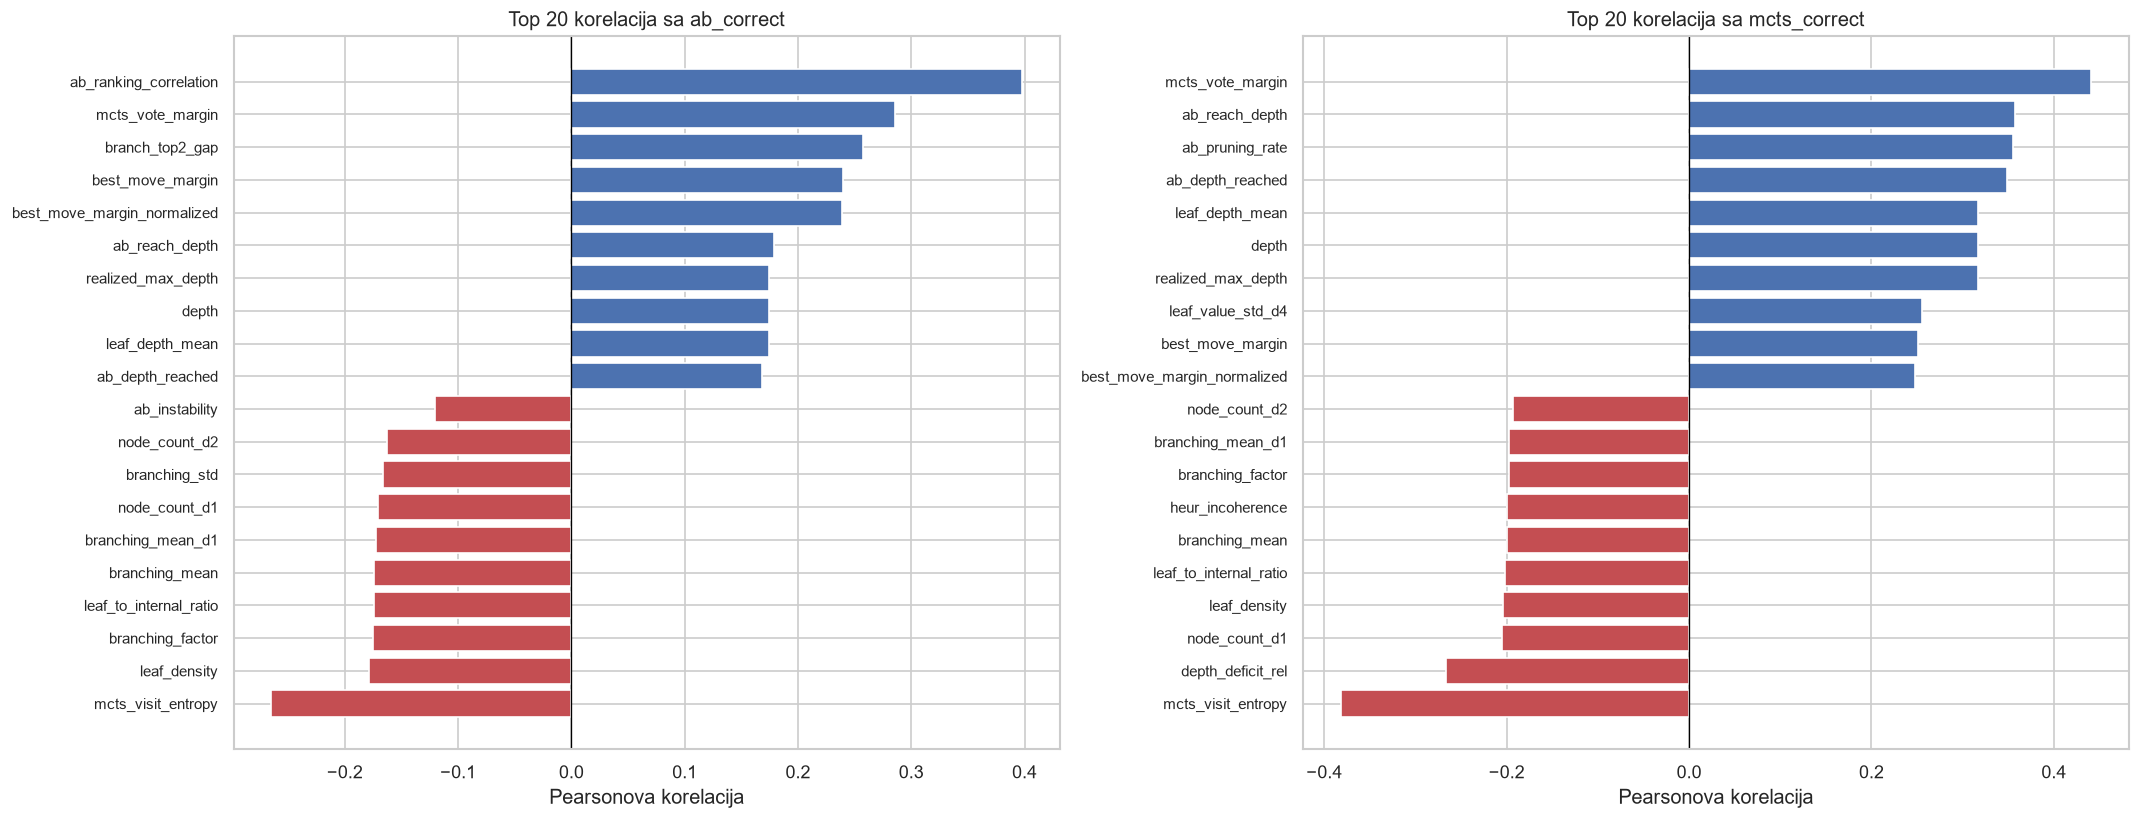

In [18]:
TARGETS_SKIP = {
    "ab_correct", "mcts_correct", "mcts_correct_rate", "is_contested",
    "delta", "ab_regret", "mcts_regret",
}

feat_num = [c for c in df.select_dtypes("number").columns
            if c not in TARGETS_SKIP and df[c].std() > 0]

targets = ["ab_correct", "mcts_correct"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, target in zip(axes, targets):
    corr = df[feat_num].corrwith(df[target]).sort_values()
    n = min(10, len(corr) // 2)
    top = pd.concat([corr.head(n), corr.tail(n)])

    ax.barh(range(len(top)), top.values,
            color=[NEG_COLOR if v < 0 else POS_COLOR for v in top.values])
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Top {2*n} korelacija sa {target}", fontsize=12)
    ax.set_xlabel("Pearsonova korelacija")

plt.tight_layout()
plt.savefig("../plots/eda/07_ab_mcts_correlation.png", bbox_inches="tight")
plt.show()

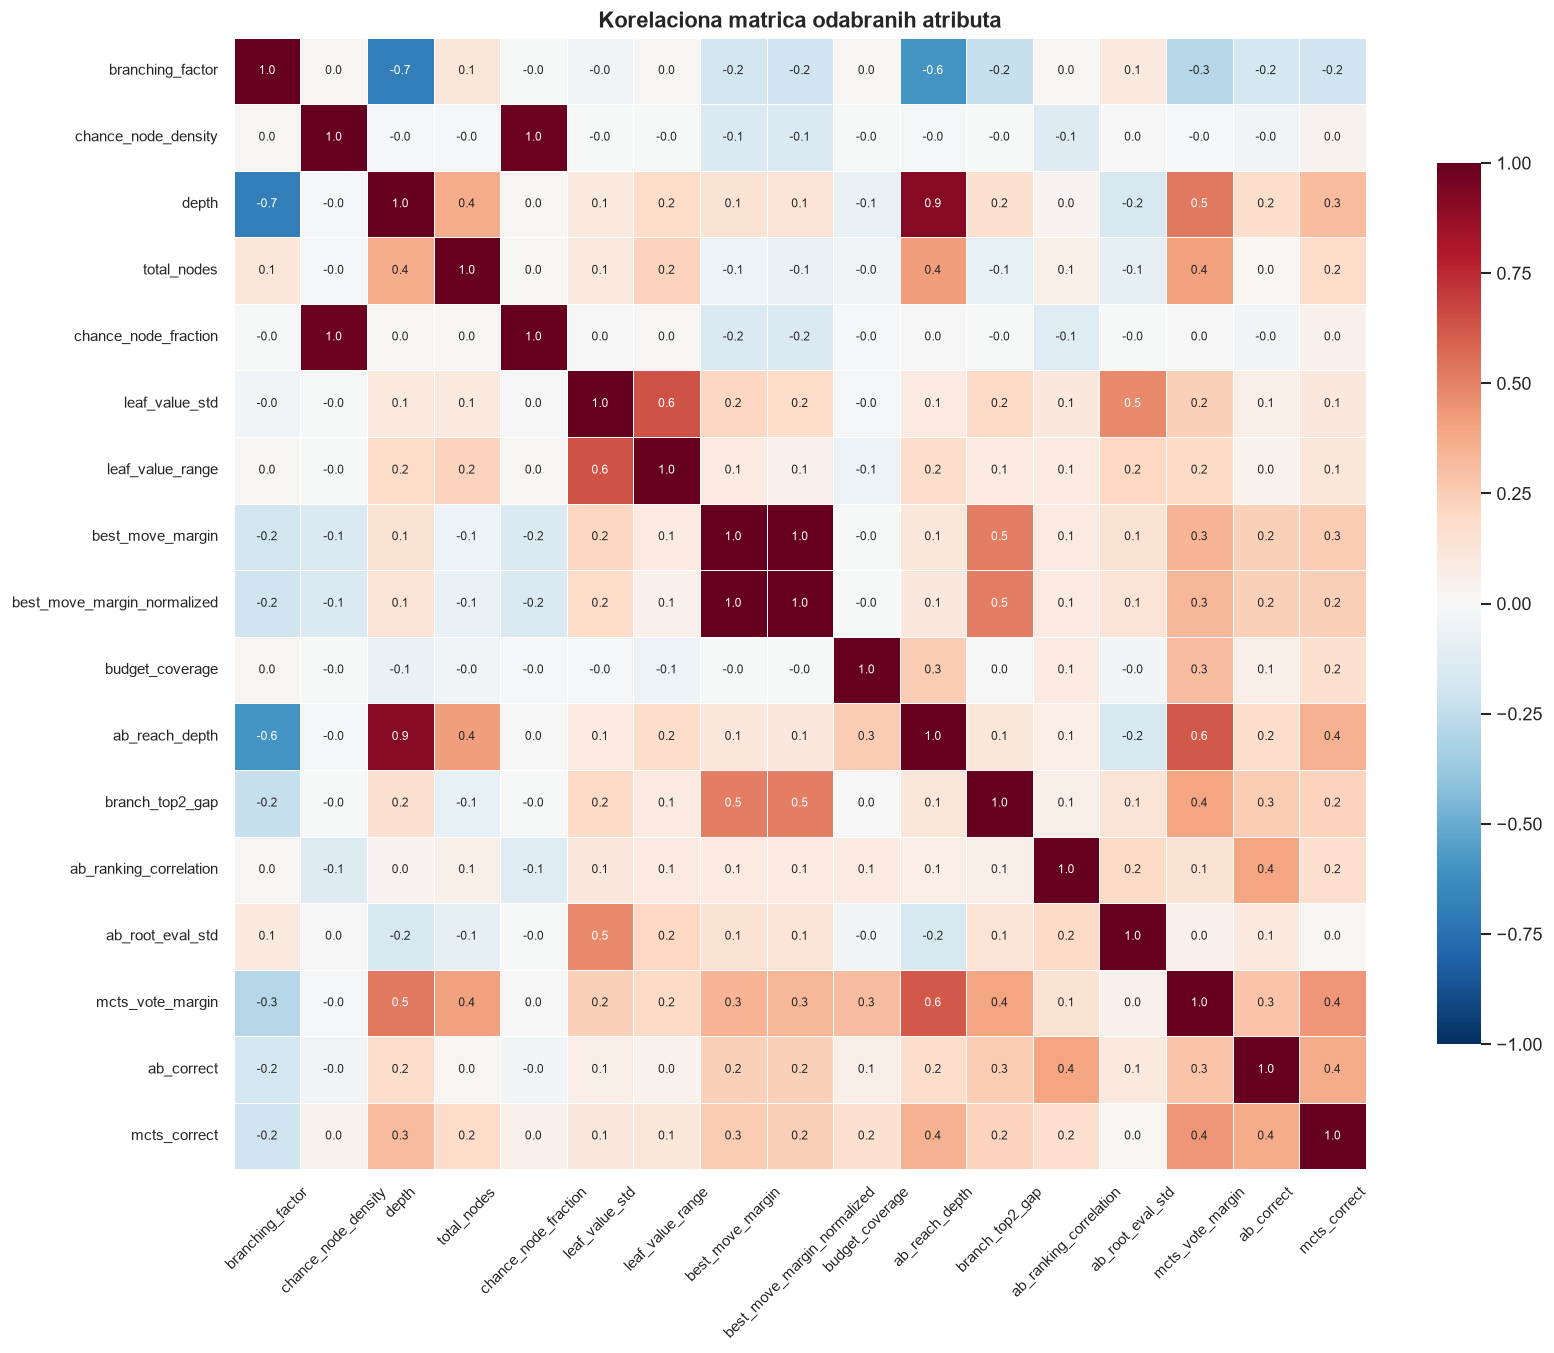

In [19]:
selected = [
    "branching_factor", "chance_node_density", "depth",
    "total_nodes", "chance_node_fraction", "leaf_value_std", "leaf_value_range",
    "best_move_margin", "best_move_margin_normalized",
    "budget_coverage", "ab_reach_depth", "branch_top2_gap",
    "ab_ranking_correlation", "ab_root_eval_std", "mcts_vote_margin",
    "ab_correct", "mcts_correct"
]


fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    df[selected].corr(), ax=ax,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".1f", annot_kws={"size": 7},
    linewidths=0.3, linecolor="white",
    square=True, cbar_kws={"shrink": 0.7}
)
ax.set_title("Korelaciona matrica odabranih atributa", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig("../plots/eda/08_correlation_matrix.png", bbox_inches="tight")
plt.show()

## 9. PCA vizualizacija u 2D

PCA na svim numeričkim atributima: da li su klase linearno razdvojive?

In [20]:
TARGETS = {
    "which_algo", "which_better", "margin_category",
    "ab_correct", "mcts_correct", "mcts_correct_rate", "is_contested",
    "delta", "ab_regret", "mcts_regret",
}
BEHAVIORAL = {
    "ab_nodes_visited", "ab_pruning_rate", "ab_root_eval_std",
    "ab_instability", "ab_depth_reached", "ab_ranking_correlation",
    "mcts_visit_entropy", "mcts_vote_margin", "mcts_best_value_estimate",
    "exact_best_value", "exact_second_best_value",
    "best_move_margin", "best_move_margin_normalized",
}

num_cols = set(df.select_dtypes("number").columns)
X = df[sorted(num_cols - TARGETS - BEHAVIORAL, key=list(df.columns).index)]

scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

print(f"Broj atributa za PCA: {X.shape[1]}")

Broj atributa za PCA: 68


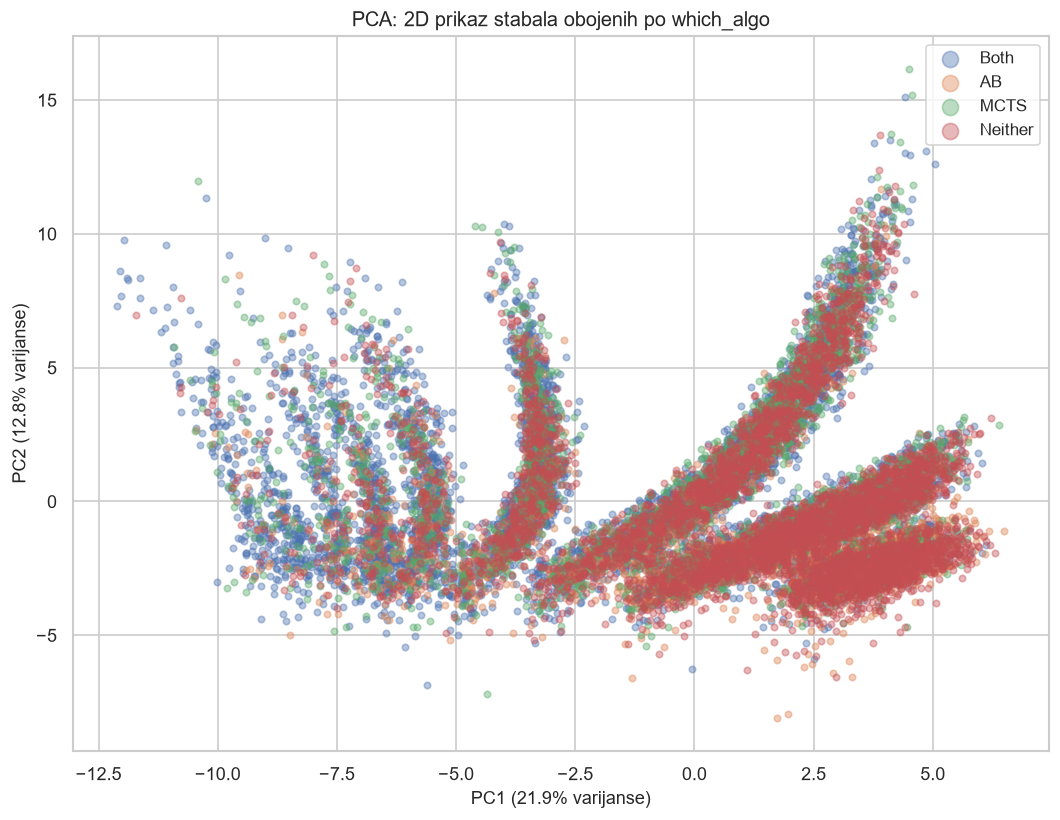

In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)

fig, ax = plt.subplots(figsize=(9, 7))
for cls in CLASS_ORDER:
    mask = df["which_algo"] == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=CLASS_COLORS[cls], label=cls, alpha=0.4, s=15)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varijanse)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varijanse)", fontsize=11)
ax.set_title("PCA: 2D prikaz stabala obojenih po which_algo", fontsize=12)
ax.legend(markerscale=2.5, fontsize=10)
plt.tight_layout()
plt.savefig("../plots/eda/09_pca_scatter.png", bbox_inches="tight")
plt.show()
# više od 60% informacija se gubi, na slici se takođe vidi da klase nisu linearno razdvojive u 2d

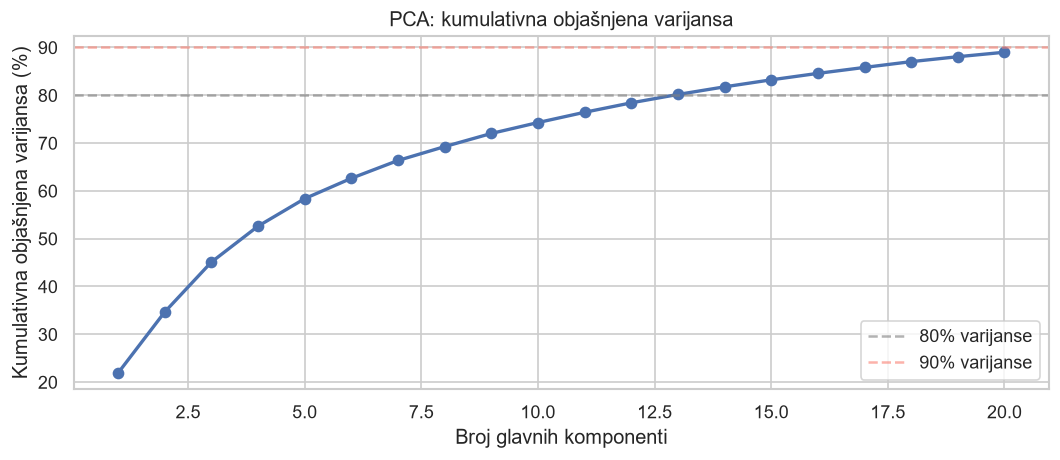

komponenti za 80% varijanse: 13


In [ ]:
pca_full = PCA(n_components=20, random_state=42).fit(X_sc)
cumulative = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 21), cumulative, "o-", color=POS_COLOR, linewidth=2)
ax.axhline(80, color="gray",   linestyle="--", alpha=0.6, label="80% varijanse")
ax.axhline(90, color="salmon", linestyle="--", alpha=0.6, label="90% varijanse")
ax.set_xlabel("Broj glavnih komponenti")
ax.set_ylabel("Kumulativna objašnjena varijansa (%)")
ax.set_title("PCA: kumulativna objašnjena varijansa")
ax.legend()
plt.tight_layout()
plt.savefig("../plots/eda/10_pca_variance.png", bbox_inches="tight")
plt.show()
n80 = int(np.argmax(cumulative >= 80)) + 1
print(f"komponenti za 80% varijanse: {n80}")

## 10. t-SNE nelinearna vizualizacija

Nelinearna redukcija dimenzija, primenjena na prvih 50 PCA komponenti

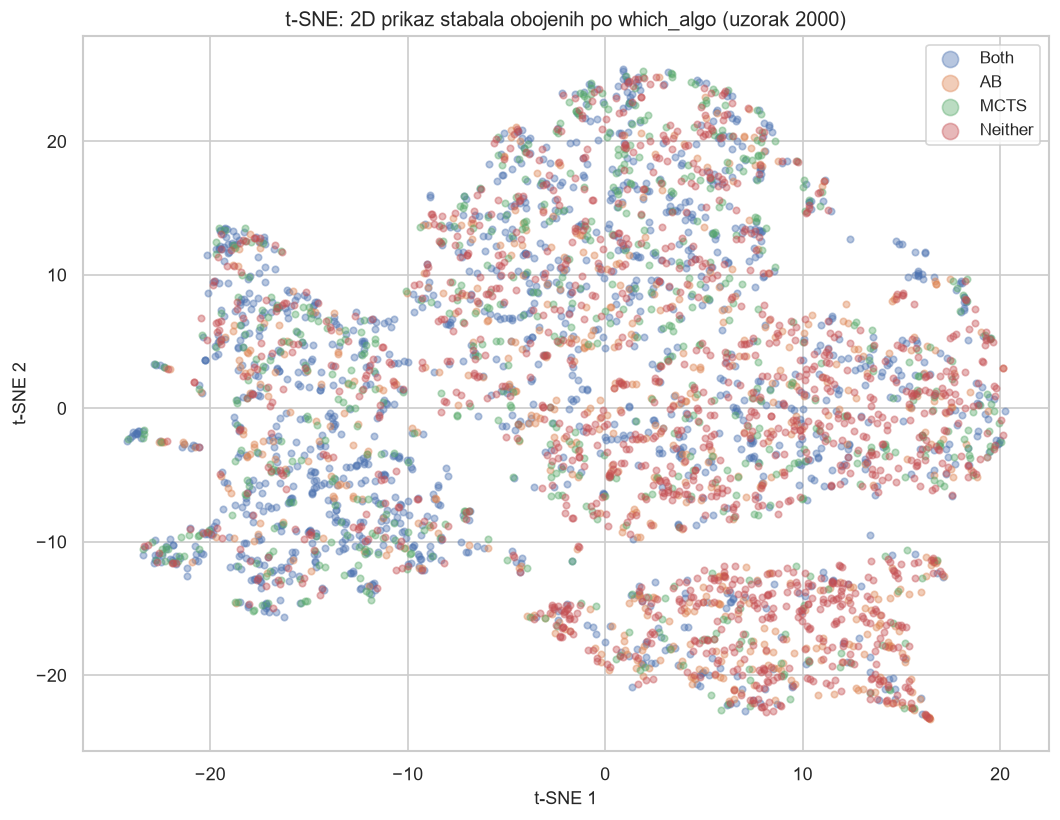

In [23]:
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=min(4000, len(df)), replace=False)

X_pca50 = PCA(n_components=26, random_state=42).fit_transform(X_sc)[idx]

tsne = TSNE(n_components=2, perplexity=30, max_iter=400, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_pca50)

labels = df["which_algo"].values[idx]

fig, ax = plt.subplots(figsize=(9, 7))
for cls in CLASS_ORDER:
    mask = labels == cls
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=CLASS_COLORS[cls], label=cls, alpha=0.4, s=15)
ax.set_xlabel("t-SNE 1", fontsize=11)
ax.set_ylabel("t-SNE 2", fontsize=11)
ax.set_title("t-SNE: 2D prikaz stabala obojenih po which_algo (uzorak 2000)", fontsize=12)
ax.legend(markerscale=2.5, fontsize=10)
plt.tight_layout()
plt.savefig("../plots/eda/11_tsne.png", bbox_inches="tight")
plt.show()